**Name:** Adline JOEKASHMIR |**Student_id:** 25690696 | **Subject:** 43031 Python Programming for Data Processing - Spring 2025

Dataset: https://www.kaggle.com/datasets/khushikyad001/smoking-and-cancer-risk-analysis


**About the Dataset:**
The Smoking Cancer dataset, hold information about comprehensive records for 3000 patients with their demographic, behavioral, environmental, medical, and survival data. These informations allows me to predict the cancer outcome upon each individuals based on lifestyle and environmental risk factors.

**Key characteristics:**

- Complete Records: Most columns are fully populated, with potential missing data in a few columns such as cancer_stage, treatment_type, cancer_type, alcohol_consumption, and occupational_hazard_exposure_level, which may require further investigation to assess data completeness.
- Balanced Gender Distribution.
- Mixed Lifestyle Habits: Provides a variety of smoking behaviors, exercise levels, and alcohol usage.
- Symptoms & Diagnosis: Flags for common cancer symptoms and corresponding diagnoses.
- Outcome Data: Useful for survival analysis with known treatment outcomes and survival status.

**Potential Use Cases and Findings:**

- Exploratory analysis of cancer risk based on lifestyle and environmental risk factors (e.g., smoking, air pollution suggesting lung cancer risk).
- Survival analysis by treatment type and cancer stage (e.g., higher survival for early stages or certain treatments) using complete outcome data.
- Feature importance insights to identify major contributing risk factors (e.g., years_smoking as a strong predictor).

This analysis will explore cancer risk patterns (cancer_type/stage) using full data and survival outcomes (survival_years) using a subset, adapting to data completeness for a holistic view.

In [1]:
# Mounting google colab to my drive to access the dataset.
try:

  from google.colab import drive
  drive.mount('/content/drive')

except Exception as e:
  print(e)

Mounted at /content/drive


In [2]:
# Inserting and printing the system path to ensure the dataset directory is accessible; this step facilitates file location in the mounted drive and helps troubleshoot path issues.
try:

  import sys
  print(sys.path)
  sys.path.insert(0,'/content/drive/MyDrive/')

except Exception as e:
  print(e)


['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']


In [3]:
# Loading the smoking_cancer dataset using Pandas. Pandas is chosen for its efficiency in handling structured CSV data and enabling robust data manipulation.

file_path = ('/content/drive/Mydrive/smoking_cancer_dataset.csv')

import pandas as pd
import numpy as np

try:
  df_raw = pd.read_csv('/content/drive/MyDrive/smoking_cancer_dataset.csv')
  #print(df_raw)
  print("The dataset loaded sucessfully!")
except FileNotFoundError:
  print(f"File not found at path: {file_path}")
except Exception as e:
  print(f"An error occurred: {e}")


The dataset loaded sucessfully!


In [4]:
# Determining the number of rows and columns in the uploaded dataset. This provides an initial overview of the dataset's size for further exploration.

x_raw = (df_raw.shape)
print("The total (rows and columns):",x_raw)

# Displaying all 24 column names to understand the attributes and their scope for analysis.
print("\n", "---- All column names are: ----")
print("\n",df_raw.columns)




The total (rows and columns): (3000, 24)

 ---- All column names are: ----

 Index(['Patient_ID', 'Age', 'Gender', 'Smoking_Status', 'Cigarettes_Per_Day',
       'Years_Smoking', 'Exposure_to_Secondhand_Smoke', 'Alcohol_Consumption',
       'BMI', 'Physical_Activity_Level', 'Diet_Quality',
       'Family_History_Cancer', 'Air_Pollution_Exposure',
       'Occupational_Hazard_Exposure', 'Chronic_Cough', 'Shortness_of_Breath',
       'Fatigue', 'Chest_Pain', 'Cancer_Type', 'Cancer_Stage', 'Diagnosis_Age',
       'Treatment_Type', 'Survival_Status', 'Survival_Years'],
      dtype='object')


In [5]:
# Displaying the top 5 rows from the dataset to inspect initial data and identify any obvious quality issues like inconsistent formatting.

print("--- The top 5 rows in the dataset ---")
print("\n",df_raw.head())



--- The top 5 rows in the dataset ---

    Patient_ID  Age  Gender Smoking_Status  Cigarettes_Per_Day  Years_Smoking  \
0           1   69   Other          Never                   0              0   
1           2   32    Male          Never                   0              0   
2           3   89   Other         Former                  11             44   
3           4   78    Male          Never                   0              0   
4           5   38  Female          Never                   0              0   

  Exposure_to_Secondhand_Smoke Alcohol_Consumption   BMI  \
0                     Moderate            Moderate  27.1   
1                     Moderate               Heavy  24.6   
2                         High               Light  29.8   
3                          Low            Moderate  19.9   
4                     Moderate            Moderate  30.7   

  Physical_Activity_Level  ... Chronic_Cough Shortness_of_Breath Fatigue  \
0                     Low  ...           Y

In [6]:
# Displaying the bottom 5 rows of the dataset to check for consistency across the data and detect potential end-of-file anomalies.

print("---The bottom 5 rows in the dataset ---")

print("\n",df_raw.tail())

---The bottom 5 rows in the dataset ---

       Patient_ID  Age  Gender Smoking_Status  Cigarettes_Per_Day  \
2995        2996   44  Female         Former                  10   
2996        2997   51  Female          Never                   0   
2997        2998   61   Other         Former                  10   
2998        2999   85  Female          Never                   0   
2999        3000   32    Male         Former                  14   

      Years_Smoking Exposure_to_Secondhand_Smoke Alcohol_Consumption   BMI  \
2995             36                     Moderate               Heavy  29.4   
2996              0                          Low               Light  22.8   
2997             47                          Low               Heavy  38.2   
2998              0                         High                 NaN  19.4   
2999             30                     Moderate                 NaN  18.3   

     Physical_Activity_Level  ... Chronic_Cough Shortness_of_Breath Fatigue  \
2

In [7]:
# Displaying the datatypes in the dataset, and this helps identify if any columns have incorrect types (e.g. numeric as object), a key quality concern.


print("\n --- The datatypes in the dataset --- ")
print(df_raw.dtypes)

# Note: All datatypes appear correct upon inspection

# Returning the total number of elements present in the dataframe
print("\n --- The size of the dataset --- ")
print(df_raw.size)



 --- The datatypes in the dataset --- 
Patient_ID                        int64
Age                               int64
Gender                           object
Smoking_Status                   object
Cigarettes_Per_Day                int64
Years_Smoking                     int64
Exposure_to_Secondhand_Smoke     object
Alcohol_Consumption              object
BMI                             float64
Physical_Activity_Level          object
Diet_Quality                     object
Family_History_Cancer            object
Air_Pollution_Exposure           object
Occupational_Hazard_Exposure     object
Chronic_Cough                    object
Shortness_of_Breath              object
Fatigue                          object
Chest_Pain                       object
Cancer_Type                      object
Cancer_Stage                     object
Diagnosis_Age                     int64
Treatment_Type                   object
Survival_Status                  object
Survival_Years                  float64


In [8]:
# Viewing basic information: row count, non-nulls, memory usage, which are useful for initial quality assessment and identifying missing data patterns.

print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    3000 non-null   int64  
 1   Age                           3000 non-null   int64  
 2   Gender                        3000 non-null   object 
 3   Smoking_Status                3000 non-null   object 
 4   Cigarettes_Per_Day            3000 non-null   int64  
 5   Years_Smoking                 3000 non-null   int64  
 6   Exposure_to_Secondhand_Smoke  3000 non-null   object 
 7   Alcohol_Consumption           2276 non-null   object 
 8   BMI                           3000 non-null   float64
 9   Physical_Activity_Level       3000 non-null   object 
 10  Diet_Quality                  3000 non-null   object 
 11  Family_History_Cancer         3000 non-null   object 
 12  Air_Pollution_Exposure        3000 non-null   object 
 13  Occ

In [9]:
# Data Dictionary
# Adding descriptions for each column to enhance understanding and provide context for analysis.

data_dictionary = {

"Patient_ID" : "A unique identifier assigned to each patient",
"Age": "Age of the patient at the time of data collection",
"Gender": "Gender of the patient; possible values include Male, Female, and Other",
"Smoking_Status": "Describes smoking history; can be Never, Former, or Current",
"Cigarettes_Per_Day": "Number of cigarettes the patient smokes per day (0 for non-smokers)",
"Years_Smoking": "Total number of years the patient has been smoking.",
"Exposure_to_Secondhand_Smoke": "Breathing in smoke which comes from other people cigareetes; Level of exposure to secondhand smoke; values: Low, Moderate, High.",
"Alcohol_Consumption": "Level of alcohol intake; values: None, Light, Moderate, Heavy.",
"BMI": "Body Mass Index; a numeric value indicating body fat based on height and weight.",
"Physical_Activity_Level": "Indicates activity level; values: Low, Moderate, High.",
"Diet_Quality": "Level of diet Quality; values: Good, Average, Poor",
"Family_History_Cancer": "Segmented into two categories: Yes, No",
"Air_Pollution_Exposure": "Exposure to Air pollution exposure, and the level of values: High, Moderate, Low",
"Occupational_Hazard_Exposure": """ Occupational Hazard exposure, in medical terms means any workplace-related exposure to harmful substances or conditions that can
increase the likelihood of developing cancer - Level of occupational hazard exposure values in the dataset is: High, Moderate, Low""",
"Chronic_Cough": "Patient have chronic cough for more than 8 weeks; values: Yes, No",
"Shortness_of_Breath": "Describes breathing issue: Values: Yes, No",
"Fatigue": "An ongoing feeling of tiredness, weakness, or lack of energy; Values: Yes, No",
"Chest_Pain": "Pain occuring on Chest; values: Yes, No",
"Cancer_Type": "Describes the type of cancer; values include Lung, Mouth, Other, throat, None (indicates no cancer was found/ missing records)",
"Cancer_Stage": "Describes the stage of cancer; values: Stage 1, Stage 2, Stage 3, Stage 4",
"Diagnosis_Age": "Age at which cancer was first identified",
"Treatment_Type": "Treatment taken to cure the cancer; values: Radiation, Chemotheraphy, Surgery, Immunotherapy, None(indicates no treatment was undergone)",
"Survival_Status": "Whether the patient is alive or deceased",
"Survival_Years": "Years survived (time measure)"
}


print(" Data column with Description:")

try:
  for keys, values in data_dictionary.items():
    print("\n",keys, ":", values)
except Exception as e:
  print(e)

 Data column with Description:

 Patient_ID : A unique identifier assigned to each patient

 Age : Age of the patient at the time of data collection

 Gender : Gender of the patient; possible values include Male, Female, and Other

 Smoking_Status : Describes smoking history; can be Never, Former, or Current

 Cigarettes_Per_Day : Number of cigarettes the patient smokes per day (0 for non-smokers)

 Years_Smoking : Total number of years the patient has been smoking.

 Exposure_to_Secondhand_Smoke : Breathing in smoke which comes from other people cigareetes; Level of exposure to secondhand smoke; values: Low, Moderate, High.

 Alcohol_Consumption : Level of alcohol intake; values: None, Light, Moderate, Heavy.

 BMI : Body Mass Index; a numeric value indicating body fat based on height and weight.

 Physical_Activity_Level : Indicates activity level; values: Low, Moderate, High.

 Diet_Quality : Level of diet Quality; values: Good, Average, Poor

 Family_History_Cancer : Segmented into

In [10]:
# Renaming columns to snake_case for consistency and easier access in Python code, improving readability for subsequent analysis.

try:
  df = df_raw.copy()

  rename_map = {
    "Patient_ID": "patient_id",
    "Age": "age",
    "Gender": "gender",
    "Smoking_Status": "smoking_status",
    "Cigarettes_Per_Day": "cigs_per_day",
    "Years_Smoking": "years_smoking",
    "Exposure_to_Secondhand_Smoke": "secondhand_smoke_exposure",
    "Alcohol_Consumption": "alcohol_consumption",
    "BMI": "bmi",
    "Physical_Activity_Level": "physical_activity_level",
    "Diet_Quality": "diet_quality",
    "Family_History_Cancer": "family_history_cancer",
    "Air_Pollution_Exposure": "air_pollution_exposure_level",
    "Occupational_Hazard_Exposure": "occupational_hazard_exposure_level",
    "Chronic_Cough": "chronic_cough",
    "Shortness_of_Breath": "shortness_of_breath",
    "Fatigue": "fatigue",
    "Chest_Pain": "chest_pain",
    "Cancer_Type": "cancer_type",
    "Cancer_Stage": "cancer_stage",
    "Diagnosis_Age": "age_at_diagnosis",
    "Treatment_Type": "treatment_type",
    "Survival_Status": "survival_status",
    "Survival_Years": "survival_years",
  }

# Displaying the new renamed columns for verification and ensuring no issues during renaming:

  old_cols = list(df_raw.columns)
  df.rename(columns=rename_map, inplace=True)
  new_cols = list(df.columns)

  # Before column rename - dataset shape
  print("\n --> Before rename (rows, columns) :",df_raw.shape)

  # After column rename - dataset shape
  print("\n --> After rename (rows, columns) :",df.shape)
  print("\n")
  print("Columns rename (old -> new):")
  print("\n")
  for old in old_cols:
    new = rename_map.get(old, old)
    if new != old:
        print("{} -> {}".format(old,new))


except Exception as e:
  print(e)


 --> Before rename (rows, columns) : (3000, 24)

 --> After rename (rows, columns) : (3000, 24)


Columns rename (old -> new):


Patient_ID -> patient_id
Age -> age
Gender -> gender
Smoking_Status -> smoking_status
Cigarettes_Per_Day -> cigs_per_day
Years_Smoking -> years_smoking
Exposure_to_Secondhand_Smoke -> secondhand_smoke_exposure
Alcohol_Consumption -> alcohol_consumption
BMI -> bmi
Physical_Activity_Level -> physical_activity_level
Diet_Quality -> diet_quality
Family_History_Cancer -> family_history_cancer
Air_Pollution_Exposure -> air_pollution_exposure_level
Occupational_Hazard_Exposure -> occupational_hazard_exposure_level
Chronic_Cough -> chronic_cough
Shortness_of_Breath -> shortness_of_breath
Fatigue -> fatigue
Chest_Pain -> chest_pain
Cancer_Type -> cancer_type
Cancer_Stage -> cancer_stage
Diagnosis_Age -> age_at_diagnosis
Treatment_Type -> treatment_type
Survival_Status -> survival_status
Survival_Years -> survival_years


In [11]:
# Displaying the renamed columns
print("Columns renamed successfully!")
# Display head - top 10 records, to confirm renaming and check initial data quality.
print("\n")
df.head(10)

Columns renamed successfully!




,patient_id,age,gender,smoking_status,cigs_per_day,years_smoking,secondhand_smoke_exposure,alcohol_consumption,bmi,physical_activity_level,...,chronic_cough,shortness_of_breath,fatigue,chest_pain,cancer_type,cancer_stage,age_at_diagnosis,treatment_type,survival_status,survival_years
0,1,69,Other,Never,0,0,Moderate,Moderate,27.1,Low,...,Yes,Yes,No,No,NaN,NaN,22,NaN,Deceased,23.4
1,2,32,Male,Never,0,0,Moderate,Heavy,24.6,Low,...,Yes,No,No,Yes,NaN,NaN,84,NaN,Alive,4.3
2,3,89,Other,Former,11,44,High,Light,29.8,Low,...,Yes,Yes,No,Yes,NaN,NaN,47,NaN,Alive,15.4
3,4,78,Male,Never,0,0,Low,Moderate,19.9,High,...,No,Yes,No,No,NaN,NaN,51,NaN,Deceased,15.7
4,5,38,Female,Never,0,0,Moderate,Moderate,30.7,Moderate,...,Yes,Yes,No,Yes,NaN,NaN,18,NaN,Deceased,29.5
5,6,41,Other,Never,0,0,Low,Light,28.4,High,...,No,No,Yes,No,Mouth,NaN,44,Surgery,Alive,29.7
6,7,20,Male,Never,0,0,High,Light,21.1,High,...,No,Yes,Yes,No,NaN,NaN,80,NaN,Deceased,24.0
7,8,39,Male,Never,0,0,Moderate,Heavy,26.3,High,...,Yes,Yes,No,No,NaN,NaN,51,NaN,Alive,14.2
8,9,70,Female,Never,0,0,Low,NaN,31.1,High,...,No,Yes,No,Yes,NaN,NaN,49,NaN,Deceased,16.4
9,10,19,Other,Never,0,0,Moderate,NaN,27.6,Low,...,Yes,No,No,No,NaN,NaN,88,NaN,Alive,9.6


In [12]:
# Finding duplicates in the raw data

try:
  d_count = df_raw.duplicated().sum()
# If any duplicates are present, print only the top 10 records
  if d_count > 0:
      d1 = (df_raw[df_raw.duplicated()].head(10))
      print(d1)
  else:
      print("No duplicates found in the dataset.")
except Exception as e:
  print(e)

No duplicates found in the dataset.


In [13]:
# Selecting and filtering columns needed for analysis;
# The selection is based on relevance to dual focus: predicting cancer risk (cancer_type/stage as targets) and survival (survival_years/status as targets).

# The below selected columns are relevant for th smoking-cancer analysis:
try:
  selected_columns = df[['age','gender','smoking_status','cigs_per_day','years_smoking','secondhand_smoke_exposure','alcohol_consumption','bmi',
                        'physical_activity_level','diet_quality','family_history_cancer','air_pollution_exposure_level','occupational_hazard_exposure_level',
                        'chronic_cough','shortness_of_breath','fatigue','chest_pain','cancer_type','cancer_stage','age_at_diagnosis','treatment_type','survival_status',
                        'survival_years']]


  # How many rows and columns in selected data?
  print("The selected data has (rows,columns): ",selected_columns.shape)

  print("\n---The selected columns for the analysis ---")
  for col in selected_columns.columns:
    print(col)

except Exception as e:
  print(e)


The selected data has (rows,columns):  (3000, 23)

---The selected columns for the analysis ---
age
gender
smoking_status
cigs_per_day
years_smoking
secondhand_smoke_exposure
alcohol_consumption
bmi
physical_activity_level
diet_quality
family_history_cancer
air_pollution_exposure_level
occupational_hazard_exposure_level
chronic_cough
shortness_of_breath
fatigue
chest_pain
cancer_type
cancer_stage
age_at_diagnosis
treatment_type
survival_status
survival_years


In [14]:
# Identifying numerical and categorical columns; this categorization guides and helps to appropriate statistical methods and emphasis the potential data type and its related quality issues.
try:

  numerical_cols = selected_columns.select_dtypes(include='number').columns
  categorical_cols = selected_columns.select_dtypes(include='object').columns

  # Counting the number of columns in each type
  count_numerical_cols = len(numerical_cols)
  count_categorical_cols = len(categorical_cols)
  total = count_categorical_cols + count_numerical_cols
  # Printing the found results
  print("Total columns present after filtering: {}" .format(total))
  print("\nNumber of numerical columns:", count_numerical_cols)
  print("Numerical columns are:")
  print(numerical_cols.to_list())
  print("\nNumber of categorical columns:", count_categorical_cols)
  print("Categorical columns are:")
  print(categorical_cols.to_list())
except Exception as e:
  print(e)

Total columns present after filtering: 23

Number of numerical columns: 6
Numerical columns are:
['age', 'cigs_per_day', 'years_smoking', 'bmi', 'age_at_diagnosis', 'survival_years']

Number of categorical columns: 17
Categorical columns are:
['gender', 'smoking_status', 'secondhand_smoke_exposure', 'alcohol_consumption', 'physical_activity_level', 'diet_quality', 'family_history_cancer', 'air_pollution_exposure_level', 'occupational_hazard_exposure_level', 'chronic_cough', 'shortness_of_breath', 'fatigue', 'chest_pain', 'cancer_type', 'cancer_stage', 'treatment_type', 'survival_status']


In [15]:
# Displaying top 10 rows of selected numerical columns to preview values and identify potential outliers.

try:
  view_num = selected_columns[numerical_cols]
  print("Top 10 rows of numerical columns:")
  print("\n",view_num.head(10))
except Exception as e:
  print(e)

Top 10 rows of numerical columns:

    age  cigs_per_day  years_smoking   bmi  age_at_diagnosis  survival_years
0   69             0              0  27.1                22            23.4
1   32             0              0  24.6                84             4.3
2   89            11             44  29.8                47            15.4
3   78             0              0  19.9                51            15.7
4   38             0              0  30.7                18            29.5
5   41             0              0  28.4                44            29.7
6   20             0              0  21.1                80            24.0
7   39             0              0  26.3                51            14.2
8   70             0              0  31.1                49            16.4
9   19             0              0  27.6                88             9.6


In [16]:
# Computing descriptive statistics, median, and variance for numerical columns and merging into a single table.
try:
    # Convert to NumPy array for median and variance calculation
    x_np = selected_columns[numerical_cols].to_numpy(dtype=float)

    # Calculate median and variance
    medians = np.median(x_np, axis=0)
    variances = np.var(x_np, axis=0)

    # Get descriptive statistics
    desc_stats = selected_columns[numerical_cols].describe()

    # Create DataFrame for median and variance
    med_var_df = pd.DataFrame({
        "median": medians,
        "variance": variances
    }, index=numerical_cols)

    # Merge descriptive stats with median and variance
    combined_stats = pd.concat([desc_stats, med_var_df.T])

    print("\nCombined descriptive statistics, median, and variance for numerical columns:")
    display(combined_stats.round(2))
except Exception as e:
    print(e)


Combined descriptive statistics, median, and variance for numerical columns:


,age,cigs_per_day,years_smoking,bmi,age_at_diagnosis,survival_years
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,52.89,5.12,12.63,25.02,52.78,15.06
std,20.68,5.54,16.23,4.86,20.59,8.61
min,18.00,0.00,0.00,9.70,18.00,0.00
25%,35.00,0.00,0.00,21.70,35.00,7.70
50%,52.00,3.00,0.00,24.95,53.00,15.10
75%,71.00,10.00,26.00,28.32,71.00,22.60
max,89.00,20.00,49.00,41.60,89.00,30.00
median,52.00,3.00,0.00,24.95,53.00,15.10
variance,427.70,30.72,263.45,23.61,423.93,74.14


**Interpretation on the Summary Statistics:**

The statistics give a quick insight into our patient data. There are 3000 records presented.

- Most are around 53 years old, with some variation, and get diagnosed around the same age, hinting at a typical cancer risk window.
- Smoking averages 5 cigs a day and 12 years, but the big spread (lots of non-smokers to heavy ones) could drive cancer risk.
- BMI sits steady at 25, though some extremes stand out.
- Survival averages 15 years, with a wide range (0 to 30), suggesting diverse outcomes.
- The quartiles help spot trends, like older ages linking to higher risk.


In [17]:
# Function for frequency tables: Added multiple frequency to comprehensively explore distributions and identify quality patterns.


try:
    def freq_table(df, col):
        t = df[col].value_counts(dropna=False).to_frame("count")
        t["percent"] = (t["count"] / len(df) * 100).round(2)
        return t.rename_axis(col).reset_index()


    f_grouping = selected_columns.groupby("gender")["cancer_stage"].value_counts(dropna=False).to_frame("count")
    f_grouping["percent"] = (f_grouping["count"] / len(selected_columns) * 100).round(2)

    print("\nTable 1: Frequency for smoking_status:")
    display(freq_table(selected_columns, "smoking_status"))
    print("\nTable 2: Frequency for cancer_type:")
    display(freq_table(selected_columns, "cancer_type"))
    print("\nTable 3: Frequency for alcohol_consumption:")
    display(freq_table(selected_columns, "alcohol_consumption"))
    print("\nTable 5: Gender wise how many people have got affected by cancer:")
    display(f_grouping.sort_index())
    print("\nTable 5: Frequency for survival_status:")
    display(freq_table(selected_columns, "survival_status"))
    print("\nTable 6: Frequency for treatment_type:")
    display(freq_table(selected_columns, "treatment_type"))
    print("\nTable 7: Frequency for physical_activity_level:")
    display(freq_table(selected_columns, "physical_activity_level"))


except Exception as e:
    print(e)




Table 1: Frequency for smoking_status:


,smoking_status,count,percent
0,Never,1487,49.57
1,Former,779,25.97
2,Current,734,24.47



Table 2: Frequency for cancer_type:


,cancer_type,count,percent
0,NaN,2076,69.20
1,Lung,423,14.10
2,Other,175,5.83
3,Mouth,166,5.53
4,Throat,160,5.33



Table 3: Frequency for alcohol_consumption:


...

,survival_status,count,percent
0,Alive,1513,50.43
1,Deceased,1487,49.57



Table 6: Frequency for treatment_type:


,treatment_type,count,percent
0,NaN,2249,74.97
1,Radiation,200,6.67
2,Immunotherapy,197,6.57
3,Chemotherapy,181,6.03
4,Surgery,173,5.77



Table 7: Frequency for physical_activity_level:


,physical_activity_level,count,percent
0,High,1046,34.87
1,Low,982,32.73
2,Moderate,972,32.40


In [18]:
# Data Quality Assessment
# Viewing missing Information for the selected columns with dtype to assess completeness.
print("Dataset info for missing checks:")

print("\n",selected_columns.info())


Dataset info for missing checks:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age                                 3000 non-null   int64  
 1   gender                              3000 non-null   object 
 2   smoking_status                      3000 non-null   object 
 3   cigs_per_day                        3000 non-null   int64  
 4   years_smoking                       3000 non-null   int64  
 5   secondhand_smoke_exposure           3000 non-null   object 
 6   alcohol_consumption                 2276 non-null   object 
 7   bmi                                 3000 non-null   float64
 8   physical_activity_level             3000 non-null   object 
 9   diet_quality                        3000 non-null   object 
 10  family_history_cancer               3000 non-null   object 
 11  air_pollut

In [19]:
# Identifying the non-standard values present in the columns which has "Object" as its data type

non_standard_values = ["N/A", "NA", "na", "n/a", "None", "none", "?", " ", "*", "&", ""]
counts = {}

for col in categorical_cols:
  counts[col] = selected_columns[col].isin(non_standard_values).sum()

print("Count of non-standard values in categorical columns:")

view_counts = pd.DataFrame(list(counts.items()), columns=['Column', 'Count'])
display(view_counts)

Count of non-standard values in categorical columns:


,Column,Count
0,gender,0
1,smoking_status,0
2,secondhand_smoke_exposure,0
3,alcohol_consumption,0
4,physical_activity_level,0
5,diet_quality,0
6,family_history_cancer,0
7,air_pollution_exposure_level,0
8,occupational_hazard_exposure_level,0
9,chronic_cough,0


In [20]:
# Count of missing values per column
try:

  missing_counts = selected_columns.isnull().sum()

  # Percentage of missing values
  missing_percent = ((missing_counts / len(selected_columns)) * 100)

  # Displaying missing value with the missing percentage
  missing_df = pd.DataFrame({
      "current_count": selected_columns.shape[0],
      "missing_count": missing_counts,
      "missing_percent": missing_percent.round(2),
      "Total_non-null_records_present": len(selected_columns) - missing_counts,
  }).sort_values(by="missing_count", ascending=False)

  print("Missing values summary:")
  display(missing_df)
except Exception as e:
  print(e)

Missing values summary:


,current_count,missing_count,missing_percent,Total_non-null_records_present
cancer_stage,3000,2259,75.30,741
treatment_type,3000,2249,74.97,751
cancer_type,3000,2076,69.20,924
occupational_hazard_exposure_level,3000,980,32.67,2020
alcohol_consumption,3000,724,24.13,2276
gender,3000,0,0.00,3000
age,3000,0,0.00,3000
secondhand_smoke_exposure,3000,0,0.00,3000
years_smoking,3000,0,0.00,3000
cigs_per_day,3000,0,0.00,3000


In [21]:
# Exploration of duplicates:
# Counting and displaying duplicates to assess data quality.

try:
  d_count = selected_columns.duplicated().sum()
# If any duplicates are present, print only the top 10 records
  if d_count > 0:
      d1 = (selected_columns[selected_columns.duplicated()].head(10))
      print(d1)
  else:
      print("No duplicates found in the dataset.")
except Exception as e:
  print(e)



No duplicates found in the dataset.


In [22]:
# Exploration of unusual values (outliers) in age and survival. Useful for a  custom checks for data integrity, by identifying issues without correction.

try:

  checks = []

  # Patient Age range plausibility
  checks.append(("age < 0", int((selected_columns["age"] < 0).sum())))
  checks.append(("age > 100", int((selected_columns["age"] > 100).sum())))

  # Survival years should not be negative or unrealistically large
  checks.append(("survival_years < 0", int((selected_columns["survival_years"] < 0).sum())))
  checks.append(("survival_years > 100", int((selected_columns["survival_years"] > 100).sum())))

  # Age at diagnosis should not be negative or unrealistically large
  checks.append(("age_at_diagnosis < 0", int((selected_columns["age_at_diagnosis"] < 0).sum())))
  checks.append(("age_at_diagnosis > 100", int((selected_columns["age_at_diagnosis"] > 100).sum())))


  plausibility_df = pd.DataFrame(checks, columns=["check","count"])
  print("Outliers & Plausibility issues in numeric fields:")
  display(plausibility_df)


except Exception as e:
  print(e)

Outliers & Plausibility issues in numeric fields:


,check,count
0,age < 0,0
1,age > 100,0
2,survival_years < 0,0
3,survival_years > 100,0
4,age_at_diagnosis < 0,0
5,age_at_diagnosis > 100,0


In [23]:
# Exploration of correlation on selected numeric columns.

corr = selected_columns[numerical_cols].corr()
print("Correlation matrix:")
display(corr.round(3))

Correlation matrix:


,age,cigs_per_day,years_smoking,bmi,age_at_diagnosis,survival_years
age,1.000,-0.018,-0.025,0.030,0.023,0.002
cigs_per_day,-0.018,1.000,0.699,0.009,0.003,-0.017
years_smoking,-0.025,0.699,1.000,0.020,0.026,0.013
bmi,0.030,0.009,0.020,1.000,-0.007,0.063
age_at_diagnosis,0.023,0.003,0.026,-0.007,1.000,0.034
survival_years,0.002,-0.017,0.013,0.063,0.034,1.000


**Interpretation of Correlation Matrix:**

The Pearson correlations matrix show some interesting ties:

•	Smoking amount (cigs_per_day) and smoking years (years_smoking) are closely tied  (r = 0.699), meaning more years often mean more cigs, a big hint for cancer risk.
•	For survival_years, the correlations with other continuous factors like age, BMI, cigs_per_day, years_smoking, and age_at_diagnosis are all very close to zero (r = -0.017 to + 0.063), this means there are almost no linear relationships between the survival time and these numerical variables.



**----  End of Assessment 2A  ----**

In [24]:
print("------- Assessment 3 Deliverable A - Python program -------")

------- Assessment 3 Deliverable A - Python program -------


# **Summary on Assessment 3:**

The **Assessment 3** will prioritize on the key findings on the "Smoking-Cancer" dataset, which will provide a detailed understanding on the causes, by which the recorded patients are prone to the risk of cancer.

The following tasks were carefully cleaned by Python, and further concluded the analysis by unwinding the key identification by answering to 8 questions which proclaim the risk patterns present in the dataset, through various visuals to ease the reader's understanding.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

Initial Data Pre-Processing Assessment
1. Data shape:
(3000, 24)

2. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          3000 non-null   int64  
 1   age                                 3000 non-null   int64  
 2   gender                              3000 non-null   object 
 3   smoking_status                      3000 non-null   object 
 4   cigs_per_day                        3000 non-null   int64  
 5   years_smoking                       3000 non-null   int64  
 6   secondhand_smoke_exposure           3000 non-null   object 
 7   alcohol_consumption                 2276 non-null   object 
 8   bmi                                 3000 non-null   float64
 9   physical_activity_level             3000 non-null   object 
 10  diet_quality             

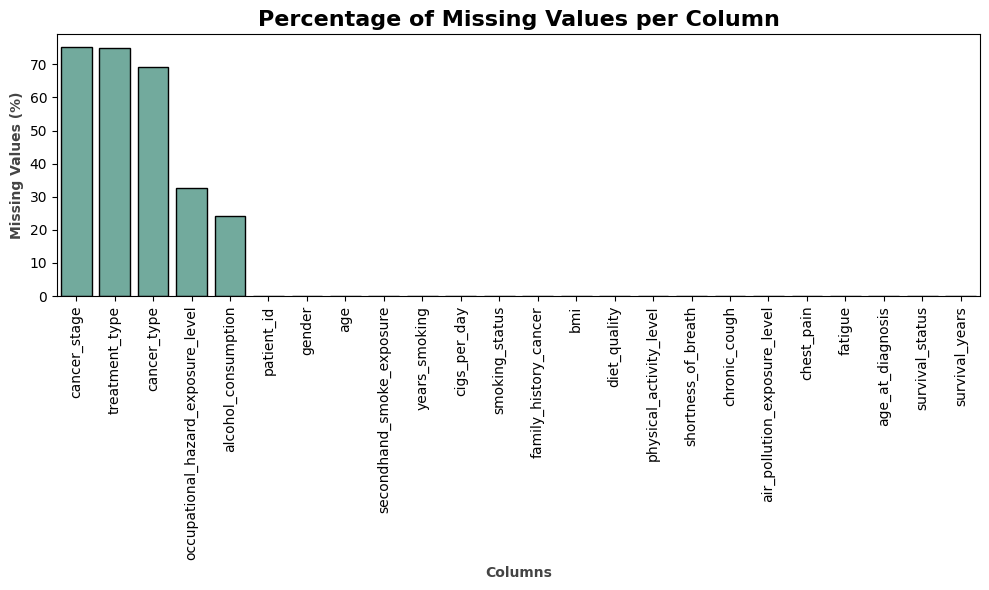


5. Checking if any Duplicate Rows present:
Duplicate Rows: No duplicate found

6. Checking if any duplicate Columns present:
Duplicate Columns:No duplicate found

7. Identifying unique values in Gender column:
['Other' 'Male' 'Female']

8. Identifying any outliers present:

Column: bmi
Q1 = 21.70, Q3 = 28.32, IQR = 6.62
Lower Bound = 11.76, Upper Bound = 38.26
Outliers found: 20

Column: age
Q1 = 35.00, Q3 = 71.00, IQR = 36.00
Lower Bound = -19.00, Upper Bound = 125.00
Outliers found: 0

Column: age_at_diagnosis
Q1 = 35.00, Q3 = 71.00, IQR = 36.00
Lower Bound = -19.00, Upper Bound = 125.00
Outliers found: 0

Column: survival_years
Q1 = 7.70, Q3 = 22.60, IQR = 14.90
Lower Bound = -14.65, Upper Bound = 44.95
Outliers found: 0

Column: years_smoking
Q1 = 0.00, Q3 = 26.00, IQR = 26.00
Lower Bound = -39.00, Upper Bound = 65.00
Outliers found: 0

Column: cigs_per_day
Q1 = 0.00, Q3 = 10.00, IQR = 10.00
Lower Bound = -15.00, Upper Bound = 25.00
Outliers found: 0


In [26]:
# Data pre-processing
try:
  print("="*60)
  print("Initial Data Pre-Processing Assessment")
  print("="*60)

  #Checking the data shape - rows and columns
  print("1. Data shape:")
  print(df.shape)

  #Checking Dtype and non-null values present in the dataset
  print("\n2. Dataset Info:")
  print(df.info())

  #Identifying the missing values - Summary detail
  print("\n3. Summary on Missing Values:")

  # Assigning percentage for the missing values
  missing_values = df.isnull().sum().sort_values(ascending=False)
  missing_p = (missing_values / len(df)) * 100
  missing_df = pd.DataFrame({
      "missing_count": missing_values,
      "missing_percent": missing_p.round(2)})
  print(missing_df)

  # Visual demonstration on the missing values
  print("\n4. Visualising the Summary on the Missing Value:")
  plt.figure(figsize=(10, 6))
  sns.barplot(x=missing_df.index, y=missing_df["missing_percent"],color="#69b3a2", edgecolor="black")
  plt.xticks(rotation=90)
  plt.title("Percentage of Missing Values per Column", fontsize=16, fontweight="bold", fontname= "DejaVu Sans",color="Black")
  plt.xlabel("Columns", fontsize=10, fontname="DejaVu Sans", weight="bold", color="#444444")
  plt.ylabel("Missing Values (%)", fontsize=10, fontname="DejaVu Sans", weight="bold", color="#444444")
  plt.tight_layout()
  plt.show()

  # Identifying any duplicates present on the row data
  print("\n5. Checking if any Duplicate Rows present:")

  check_dp = df.duplicated().sum()
  if check_dp > 0:
    print("Duplicate Rows:".format(check_dp))
  else:
    print("Duplicate Rows: No duplicate found")

  # Identifying any duplicates present on the column data
  print("\n6. Checking if any duplicate Columns present:")
  check_dp = df.T.duplicated().sum()
  if check_dp > 0:
    print("Duplicate Columns:{}".format(check_dp))
  else:
    print("Duplicate Columns:No duplicate found")

  # Sanity Check made on Gender column
  print("\n7. Identifying unique values in Gender column:")
  print(df["gender"].unique())

  # Identigying the presence of Outliers
  print("\n8. Identifying any outliers present:")
  numeric_cols = ['bmi', 'age', 'age_at_diagnosis','survival_years',  'years_smoking', 'cigs_per_day']

  for col in numeric_cols:
    if col in df.columns:
      data = df[col].values
      Q1 = np.percentile(data, 25)
      Q3 = np.percentile(data, 75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      outliers = [x for x in data if x < lower_bound or x > upper_bound]
      print("\n" + "="*60)
      print("Column: {}".format(col))
      print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
      print(f"Lower Bound = {lower_bound:.2f}, Upper Bound = {upper_bound:.2f}")
      print(f"Outliers found: {len(outliers)}")





except Exception as e:
  print(e)




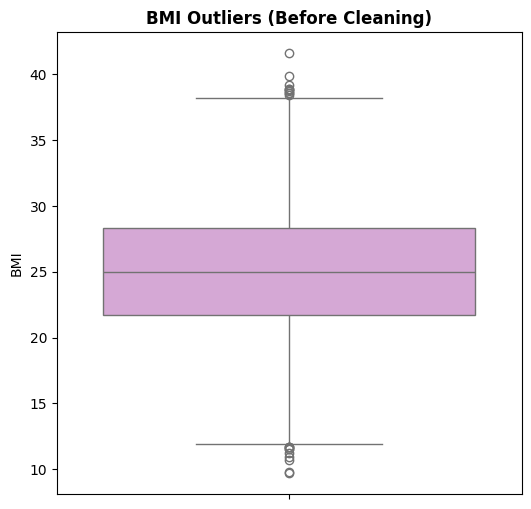

In [27]:
# Visualising the BMI outliers (After cleaning) using Box plot

try:
  plt.figure(figsize=(6, 6))
  sns.boxplot(y=df['bmi'], color='plum')
  plt.title("BMI Outliers (Before Cleaning)", fontsize=12, fontweight="bold")
  plt.ylabel("BMI")
  plt.show()
except Exception as e:
  print(e)

In [28]:
# Handling Missing Values:

try:
  print("="*60)
  print("Handling Missing Values")
  print("="*60)

  # Data Shape
  print("\n1. Display dataset shape:")
  print("Data Shape (Before handling missing values): {}".format(df.shape))

  # Columns with high missing values
  high_missing_cols = missing_p[missing_p > 50].index
  print("\n2. Columns with missing values greater than 50% (High-missing values columns):")
  print(high_missing_cols)

  # Columns with moderate missing values
  moderate_missing_cols = missing_p[(missing_p > 0) & (missing_p <= 50)].index
  print("\n3. Columns with missing values less than 50% (Moderate-missing values columns):")
  print(moderate_missing_cols)

  #Dropping Columns which have high missing values
  total_rows = len(df)
  df_clean = df.dropna(subset=high_missing_cols).drop(columns='patient_id')


  # Dropping Column which have moderate missing values using mode
  for x in moderate_missing_cols:
    if x in df_clean.columns:
        mode_value = df_clean[x].mode()[0]
        df_clean[x] = df_clean[x].fillna(mode_value)
        print("\n4. Imputed {} with mode: {}".format(x, mode_value))
  print("\n5. Rows before dropping high-missing: {}".format(total_rows))
  print("\n6. Rows after dropping high-missing: {}".format(len(df_clean)))
  print("\n7. Data Retained: {}%".format(round((len(df_clean)/total_rows)*100,2)))
  print("\n8. Column Dropped: patient_id")



  # Finding the missing values count after cleaning the data
  print("\n9. Missing Values After cleaning:")
  print(df_clean.isnull().sum().sort_values(ascending=False))

  print("\n10. Cleaned Dataset:")
  print(df_clean.info())

  # Final Shape
  print(f"\n11. Final Data Shape: {df_clean.shape}")



except Exception as e:
  print(e)



Handling Missing Values

1. Display dataset shape:
Data Shape (Before handling missing values): (3000, 24)

2. Columns with missing values greater than 50% (High-missing values columns):
Index(['cancer_stage', 'treatment_type', 'cancer_type'], dtype='object')

3. Columns with missing values less than 50% (Moderate-missing values columns):
Index(['occupational_hazard_exposure_level', 'alcohol_consumption'], dtype='object')

4. Imputed occupational_hazard_exposure_level with mode: Low

4. Imputed alcohol_consumption with mode: Heavy

5. Rows before dropping high-missing: 3000

6. Rows after dropping high-missing: 604

7. Data Retained: 20.13%

8. Column Dropped: patient_id

9. Missing Values After cleaning:
age                                   0
gender                                0
smoking_status                        0
cigs_per_day                          0
years_smoking                         0
secondhand_smoke_exposure             0
alcohol_consumption                   0
bmi  

In [29]:
# "Outlier Handling with IQR"
# Identifying the outliers presented for all the numeric_cols on cleaned dataset

try:
    import numpy as np


    numeric_cols = ['bmi', 'age', 'age_at_diagnosis','survival_years', 'years_smoking', 'cigs_per_day']
    print("="*60)
    print("OUTLIER HANDLING WITH IQR CLIPPING")


    for col in numeric_cols:
        if col in df_clean.columns:
            data = df_clean[col].values
            Q1 = np.percentile(data, 25)
            Q3 = np.percentile(data, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR


            outliers = [x for x in data if x < lower_bound or x > upper_bound]
            print("\n" + "="*60)
            print("Column: {}".format(col))
            print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
            print(f"Lower Bound = {lower_bound:.2f}, Upper Bound = {upper_bound:.2f}")
            print(f"Outliers found: {len(outliers)}")



except Exception as e:
    print(f"Error in outlier handling: {e}")

OUTLIER HANDLING WITH IQR CLIPPING

Column: bmi
Q1 = 21.60, Q3 = 28.60, IQR = 7.00
Lower Bound = 11.10, Upper Bound = 39.10
Outliers found: 2

Column: age
Q1 = 34.00, Q3 = 72.00, IQR = 38.00
Lower Bound = -23.00, Upper Bound = 129.00
Outliers found: 0

Column: age_at_diagnosis
Q1 = 35.00, Q3 = 71.00, IQR = 36.00
Lower Bound = -19.00, Upper Bound = 125.00
Outliers found: 0

Column: survival_years
Q1 = 7.97, Q3 = 23.42, IQR = 15.45
Lower Bound = -15.20, Upper Bound = 46.60
Outliers found: 0

Column: years_smoking
Q1 = 0.00, Q3 = 26.00, IQR = 26.00
Lower Bound = -39.00, Upper Bound = 65.00
Outliers found: 0

Column: cigs_per_day
Q1 = 0.00, Q3 = 10.00, IQR = 10.00
Lower Bound = -15.00, Upper Bound = 25.00
Outliers found: 0


Deduction for Outliers - 'BMI'

What are the outliers in BMI (Before & After Cleaning Dataset)


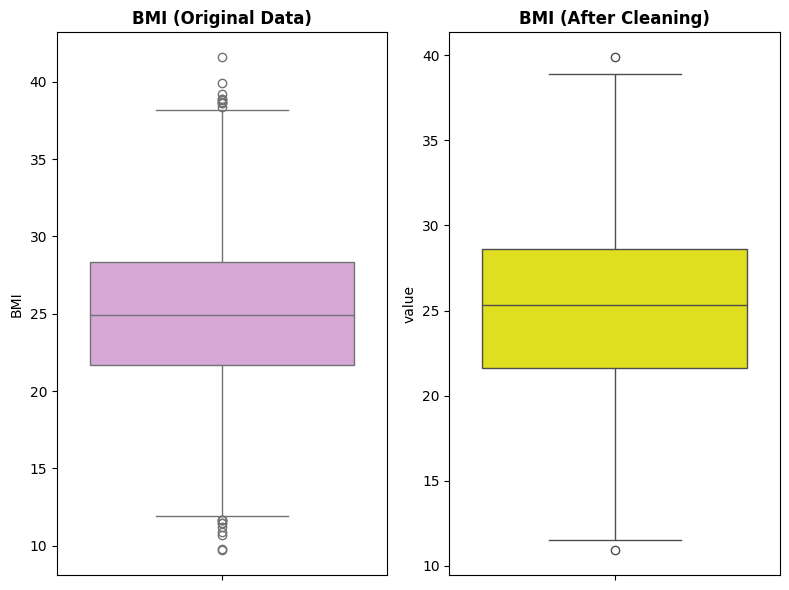


Findings: BMI outliers appear as dots beyond whiskers in both plots. The left-side chart provides the visual on the deduction for the outliers before cleaning the data,
              and the chart on the right-side shows the minimal deduction on the outliers with only 2. After cleaning the dataset, spread of the outliers were reduced and the values sits at 39.90 and 10.9 above and below the whisk of the box plot


In [30]:
# Box-plot for outliers present - BMI
try:

    print("="*60)
    print("Deduction for Outliers - 'BMI'")
    print("="*60)
    print("\nWhat are the outliers in BMI (Before & After Cleaning Dataset)")

    plt.figure(figsize=(8, 6))

    # Original data (df) - before cleaning the dataset
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df['bmi'], color='plum')
    plt.title("BMI (Original Data)", fontsize=12, fontweight="bold")
    plt.ylabel("BMI")

    # Cleaned data (df_clean) -After cleaning teh dataset
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_clean['bmi'], color='yellow')
    plt.title("BMI (After Cleaning)", fontsize=12, fontweight="bold")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

    print("""\nFindings: BMI outliers appear as dots beyond whiskers in both plots. The left-side chart provides the visual on the deduction for the outliers before cleaning the data,
              and the chart on the right-side shows the minimal deduction on the outliers with only 2. After cleaning the dataset, spread of the outliers were reduced and the values sits at 39.90 and 10.9 above and below the whisk of the box plot""")



except Exception as e:
  print(e)

In [31]:
# Displaying the top 10 and bottom  10 rows of the cleaned dataset

print("The top 10 rows are:")
df_clean.head(10)

The top 10 rows are:


,age,gender,smoking_status,cigs_per_day,years_smoking,secondhand_smoke_exposure,alcohol_consumption,bmi,physical_activity_level,diet_quality,...,chronic_cough,shortness_of_breath,fatigue,chest_pain,cancer_type,cancer_stage,age_at_diagnosis,treatment_type,survival_status,survival_years
20,76,Male,Never,0,0,High,Moderate,27.9,Low,Good,...,Yes,No,No,No,Lung,Stage IV,77,Radiation,Alive,22.5
21,59,Other,Former,11,27,High,Light,32.1,Moderate,Good,...,No,Yes,No,No,Throat,Stage IV,46,Immunotherapy,Alive,18.6
23,32,Male,Former,8,3,Moderate,Light,20.9,Low,Average,...,Yes,No,No,Yes,Mouth,Stage II,56,Immunotherapy,Alive,10.0
24,79,Male,Never,0,0,High,Light,26.5,Low,Average,...,No,No,No,Yes,Mouth,Stage IV,79,Surgery,Alive,4.3
26,64,Male,Current,11,48,Low,Heavy,24.5,Moderate,Good,...,Yes,Yes,No,Yes,Mouth,Stage III,62,Radiation,Deceased,24.6
33,24,Other,Never,0,0,Moderate,Light,27.4,Moderate,Average,...,No,Yes,No,Yes,Lung,Stage IV,77,Immunotherapy,Deceased,15.7
42,19,Other,Never,0,0,Low,Heavy,24.9,High,Good,...,Yes,Yes,Yes,No,Throat,Stage II,51,Immunotherapy,Deceased,5.2
45,61,Other,Never,0,0,Moderate,Moderate,17.3,High,Average,...,No,Yes,No,No,Lung,Stage III,46,Surgery,Alive,14.7
46,25,Male,Never,0,0,Low,Moderate,21.0,Low,Good,...,Yes,Yes,No,No,Mouth,Stage IV,26,Immunotherapy,Alive,3.2
61,79,Male,Current,9,30,High,Moderate,23.0,Low,Good,...,Yes,Yes,No,No,Mouth,Stage IV,85,Radiation,Alive,8.1


In [32]:
print("The top 10 bottom rows are:")
df_clean.tail(10)

The top 10 bottom rows are:


,age,gender,smoking_status,cigs_per_day,years_smoking,secondhand_smoke_exposure,alcohol_consumption,bmi,physical_activity_level,diet_quality,...,chronic_cough,shortness_of_breath,fatigue,chest_pain,cancer_type,cancer_stage,age_at_diagnosis,treatment_type,survival_status,survival_years
2949,36,Other,Never,0,0,Low,Heavy,13.6,Moderate,Average,...,Yes,No,No,No,Throat,Stage IV,73,Chemotherapy,Deceased,3.1
2959,71,Female,Never,0,0,High,Light,26.1,High,Good,...,No,No,Yes,No,Other,Stage IV,64,Radiation,Deceased,17.0
2962,49,Female,Current,7,49,High,Heavy,31.0,High,Poor,...,Yes,Yes,No,Yes,Other,Stage III,21,Chemotherapy,Alive,24.0
2963,31,Other,Former,13,3,High,Moderate,27.3,Low,Poor,...,No,No,No,Yes,Other,Stage I,61,Chemotherapy,Alive,15.2
2968,39,Other,Current,12,47,Moderate,Light,22.7,Low,Average,...,Yes,No,Yes,Yes,Lung,Stage III,62,Chemotherapy,Alive,10.0
2969,47,Other,Current,13,19,High,Moderate,32.2,Moderate,Good,...,Yes,Yes,Yes,Yes,Lung,Stage III,63,Immunotherapy,Alive,2.8
2974,29,Female,Never,0,0,Moderate,Moderate,23.0,High,Good,...,No,Yes,Yes,Yes,Mouth,Stage IV,27,Radiation,Deceased,22.3
2982,67,Other,Current,9,31,Moderate,Moderate,30.0,Moderate,Poor,...,No,No,Yes,No,Lung,Stage IV,83,Immunotherapy,Deceased,17.4
2994,26,Male,Never,0,0,High,Heavy,29.5,Moderate,Poor,...,No,No,Yes,No,Throat,Stage II,52,Surgery,Deceased,13.4
2999,32,Male,Former,14,30,Moderate,Heavy,18.3,Moderate,Good,...,Yes,No,Yes,No,Mouth,Stage III,70,Surgery,Alive,16.6


In [33]:
# Final Describe Summary on cleaned data:
try:
  print("Final Data Summary:")
  final = df_clean.select_dtypes(include='number').describe()
  final.loc['variance'] = df_clean[final.columns].var()
  final.loc['median'] = df_clean[final.columns].median()
  display(final.round(2))
except Exception as e:
  print(e)


Final Data Summary:


,age,cigs_per_day,years_smoking,bmi,age_at_diagnosis,survival_years
count,604.00,604.00,604.00,604.00,604.00,604.00
mean,53.23,5.14,13.19,25.23,52.51,15.27
std,20.94,5.37,16.46,4.94,20.63,8.68
min,18.00,0.00,0.00,10.90,18.00,0.00
25%,34.00,0.00,0.00,21.60,35.00,7.98
50%,53.00,5.00,2.50,25.30,52.00,15.70
75%,72.00,10.00,26.00,28.60,71.00,23.42
max,89.00,19.00,49.00,39.90,89.00,30.00
variance,438.31,28.78,270.91,24.36,425.62,75.30
median,53.00,5.00,2.50,25.30,52.00,15.70


•	The mean of patient age and age at diagnosis are 53 years.
•	Average cigarette consumption is 5 per-day for 13 years, with a maximum of 19 cigarettes-per-day for 49 years.
•	Mean BMI is 25, which indicates most patients are slightly overweight, ranging from 10-39, indicating underweight to obese individuals.
•	Post-cancer diagnosis survival ranges between (0-30 years), with an average lifespan of 15 years.


In [34]:
# Final Correlation Summary on cleaned data:
try:
  print("Correaltion Summary on cleaned Dataset:")
  cor_new = df_clean.select_dtypes(include=['int64', 'float64']).corr()
  display(cor_new.round(3))
except Exception as e:
  print(e)

Correaltion Summary on cleaned Dataset:


,age,cigs_per_day,years_smoking,bmi,age_at_diagnosis,survival_years
age,1.000,-0.034,-0.039,0.014,0.041,-0.030
cigs_per_day,-0.034,1.000,0.676,0.102,0.027,0.001
years_smoking,-0.039,0.676,1.000,0.081,0.059,0.062
bmi,0.014,0.102,0.081,1.000,-0.041,0.016
age_at_diagnosis,0.041,0.027,0.059,-0.041,1.000,0.005
survival_years,-0.030,0.001,0.062,0.016,0.005,1.000


What is the correlationship between the numerical values present in the dataset


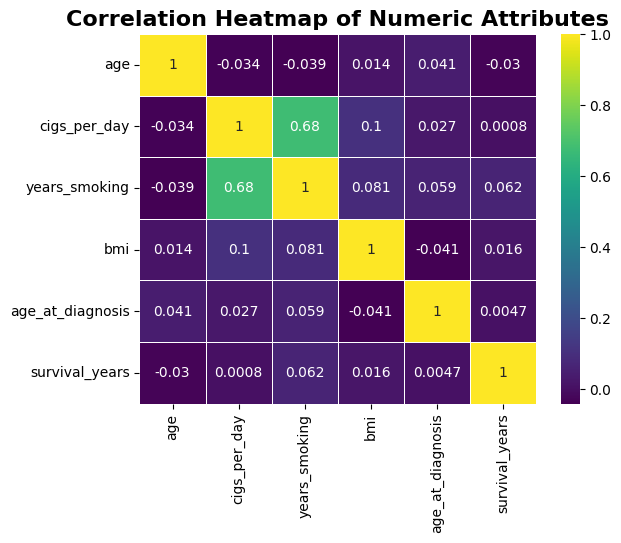


Findings: 'Cigs per day' and 'Years smoking' show a strong positive correlation, and other variables have weak or no correlation.


In [46]:
try:
  #What is the correlationship between the numerical values present in the dataset:
  print("What is the correlationship between the numerical values present in the dataset")
  df_clean_numerical_cols = df_clean.select_dtypes(include=['int64', 'float64'])
  view_corr = df_clean[df_clean_numerical_cols.columns].corr()

  sns.heatmap(view_corr, annot=True, xticklabels=view_corr.columns, yticklabels=view_corr.columns,linewidths=0.5, cmap='viridis')
  plt.title("Correlation Heatmap of Numeric Attributes", fontsize=16, fontweight="bold")
  plt.show()

  print("\nFindings: 'Cigs per day' and 'Years smoking' show a strong positive correlation, and other variables have weak or no correlation.")


except Exception as e:
  print(e)

Data Visualisations:

Q1. What is the age distribution of the patients in the dataset?


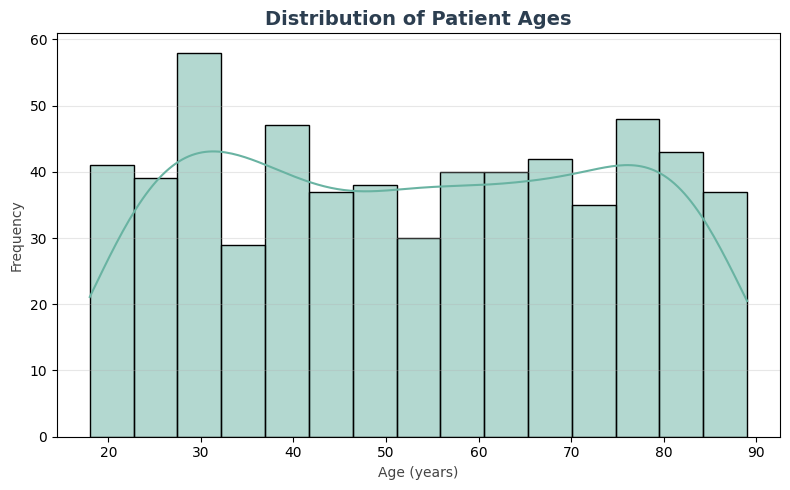


Findings: The histogram shows that most of the patients age are situated between
           the age of '30 and 75 years old',with very few below 25 or above 80.
           This indicates that the majority of patients in this dataset are middle-aged to older adults  


In [35]:
# Data Visualisation

try:
  print("="*60)
  print("Data Visualisations:")
  print("="*60)

  # Age Distribution in Histogram:
  print("\nQ1. What is the age distribution of the patients in the dataset?")

  plt.figure(figsize=(8,5))
  sns.histplot(df_clean['age'],bins=15, kde=True,color="#69b3a2", edgecolor='black')
  plt.title("Distribution of Patient Ages", fontsize=14, fontweight="bold", color="#2c3e50")
  plt.xlabel("Age (years)", fontsize=10, fontname="DejaVu Sans",  color="#444444")
  plt.ylabel("Frequency", fontsize=10, fontname="DejaVu Sans", color="#444444")
  plt.grid(axis='y', alpha=0.3)
  plt.tight_layout()
  plt.show()

  print("""\nFindings: The histogram shows that most of the patients age are situated between
           the age of '30 and 75 years old',with very few below 25 or above 80.
           This indicates that the majority of patients in this dataset are middle-aged to older adults  """)

except Exception as e:
  print(e)


Q2. What is the gender distribution of the patients in the dataset?


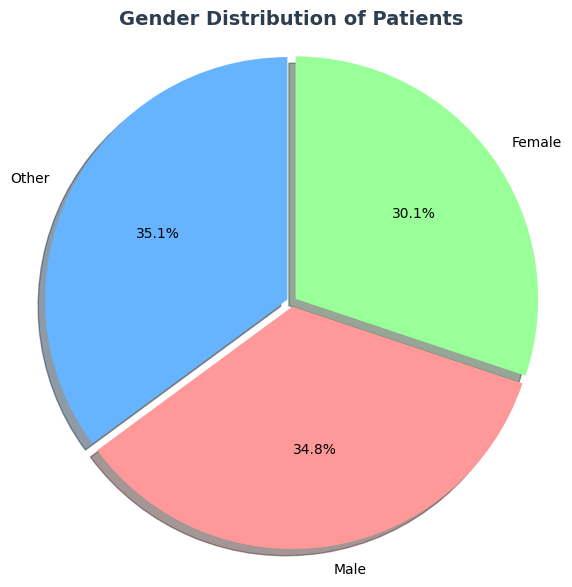


Findings: The chart shows that patients identifying as 'Other' form the largest group (35.1%), followed closely by males(34.8%) and females(30.1%).


In [36]:
try:
# Gender distribution among patients shown in Pie-Chart
  print("\nQ2. What is the gender distribution of the patients in the dataset?")
  gender_categories = df_clean['gender'].value_counts()
  plt.figure(figsize=(7,7))
  plt.pie(
      gender_categories, labels= gender_categories.index,autopct='%1.1f%%',startangle=90,
      colors = ['#66b3ff', '#ff9999', '#99ff99'], explode=(0.02, 0.02, 0.02),
      shadow=True
  )
  plt.title("Gender Distribution of Patients", fontsize=14, fontweight="bold", color="#2c3e50")
  plt.axis('equal')
  plt.show()

  print("""\nFindings: The chart shows that patients identifying as 'Other' form the largest group (35.1%), followed closely by males(34.8%) and females(30.1%).""")
except Exception as e:
  print(e)


Q3. How does smoking behaviour various across patients by the gender


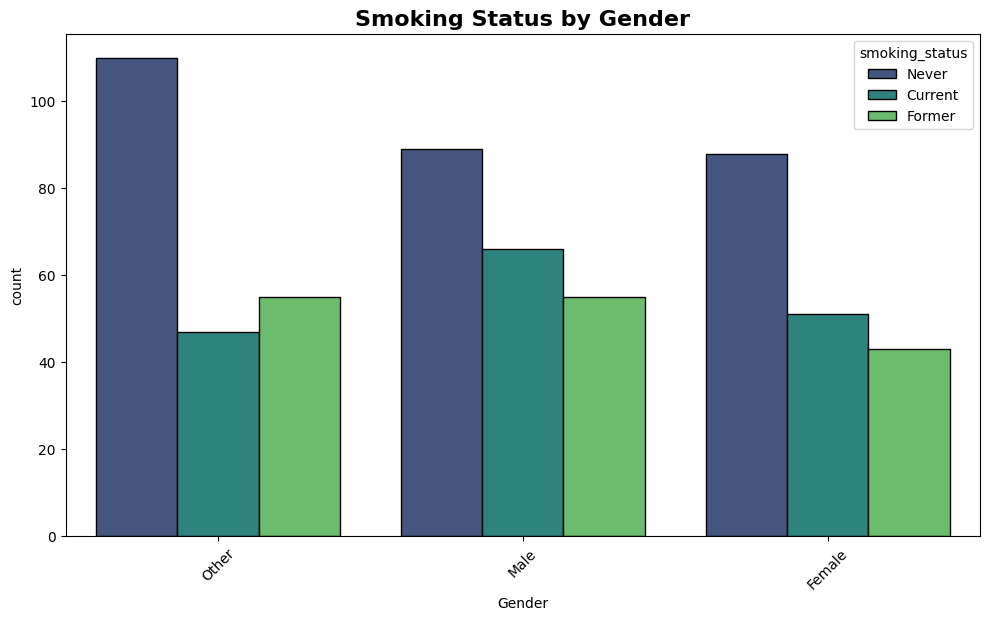


Findings: Result shows that the Active smokers are from Male category with more count on 'Current' smoking status follwed by 'Former' smokers. Whereas there a very few smokers listed under womens'  


In [37]:
try:

  print("Q3. How does smoking behaviour various across patients by the gender")
  counts_df=df_clean[['gender','smoking_status']].value_counts().reset_index(name="count")
  plt.figure(figsize=(10,6))
  sns.barplot(data=counts_df,x="gender",y="count",hue="smoking_status",palette="viridis",edgecolor="black")
  plt.title("Smoking Status by Gender", fontsize=16, fontweight="bold")
  plt.xlabel("Gender")
  plt.tight_layout()
  plt.xticks(rotation=45)
  plt.show()

  print("\nFindings: Result shows that the Active smokers are from Male category with more count on 'Current' smoking status follwed by 'Former' smokers. Whereas there a very few smokers listed under womens'  ")
except Exception as e:
  print(e)




Q4.a. How does lifestyle (smoking status) relate to cancer stage?


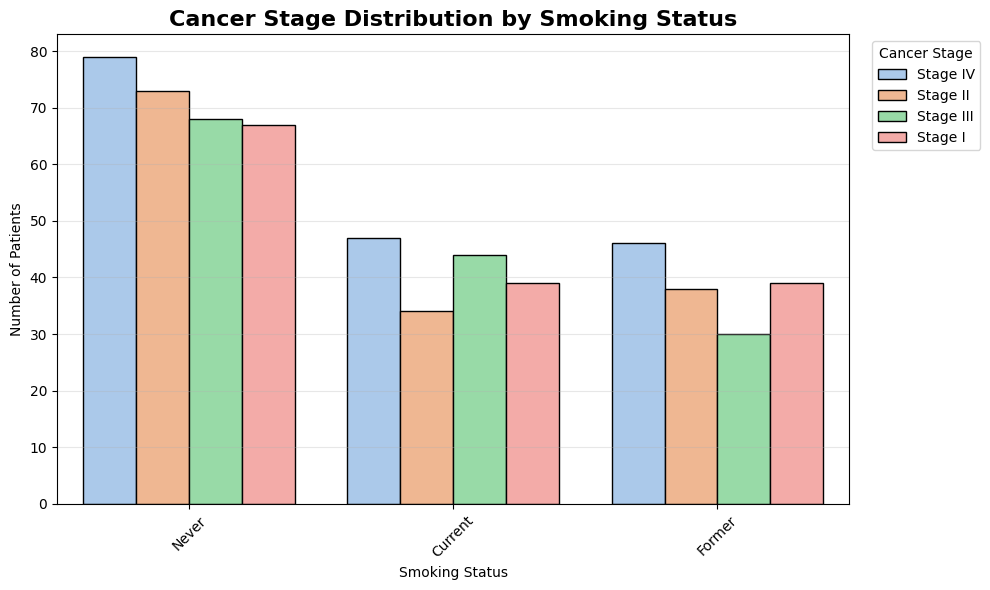


Findings: It shows that people who are 'non-smokers' are the highly effected patients by cancer 'Stage IV', and 'Stage II'


In [38]:
try:
  # Smoking Status vs Cancer Stage
  print("\nQ4.a. How does lifestyle (smoking status) relate to cancer stage?")

  counts_df = (df_clean[["smoking_status","cancer_stage"]].value_counts().reset_index(name="count"))
  plt.figure(figsize=(10,6))
  sns.barplot(data=counts_df,x="smoking_status",y="count",hue="cancer_stage",palette="pastel",edgecolor="black")

  plt.title("Cancer Stage Distribution by Smoking Status", fontsize=16, fontweight="bold")
  plt.xlabel("Smoking Status")
  plt.ylabel("Number of Patients")
  plt.legend(title="Cancer Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
  plt.grid(axis='y', alpha=0.3)
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

  print("\nFindings: It shows that people who are 'non-smokers' are the highly effected patients by cancer 'Stage IV', and 'Stage II'")

except Exception as e:
  print(e)



Q4b. How does alcohol consumption affect survival years by cancer stage?


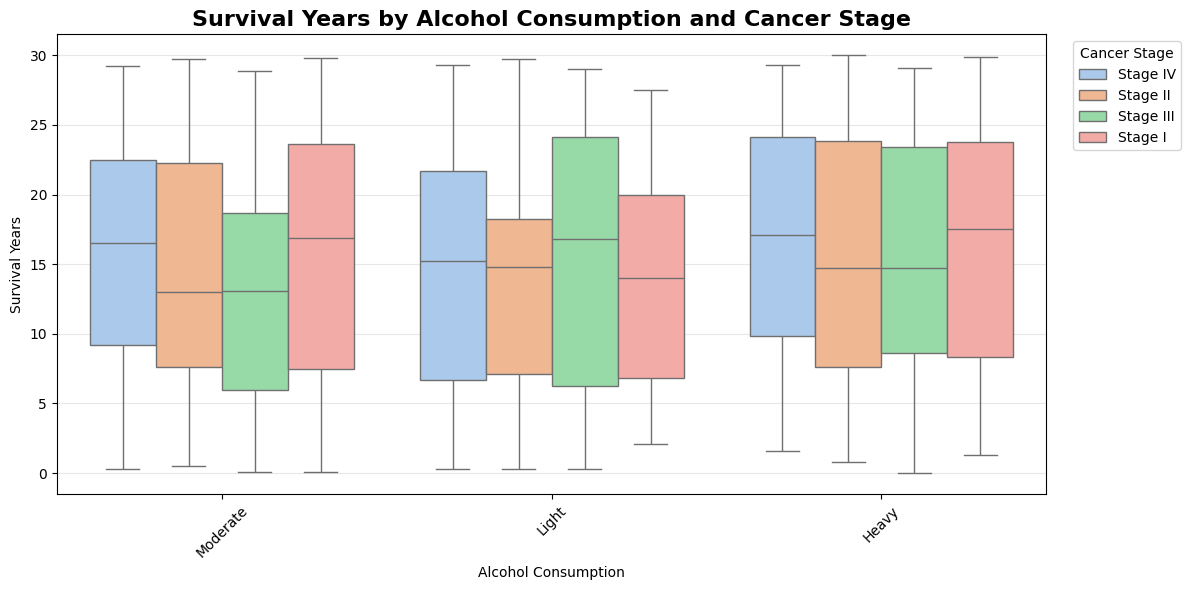


Findings: Heavy alcohol users in Stage IV, suggesting alcohol worsens advanced cancer outcomes.


In [39]:
try:
    print("\nQ4b. How does alcohol consumption affect survival years by cancer stage?")
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_clean, x='alcohol_consumption', y='survival_years', hue='cancer_stage', palette='pastel')
    plt.title("Survival Years by Alcohol Consumption and Cancer Stage", fontsize=16, fontweight="bold")
    plt.xlabel("Alcohol Consumption")
    plt.ylabel("Survival Years")
    plt.xticks(rotation=45)
    plt.legend(title="Cancer Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nFindings: Heavy alcohol users in Stage IV, suggesting alcohol worsens advanced cancer outcomes.")
except Exception as e:
    print(e)

Q5.a. Cancer Diagnosed age based on Patients Diet Quality


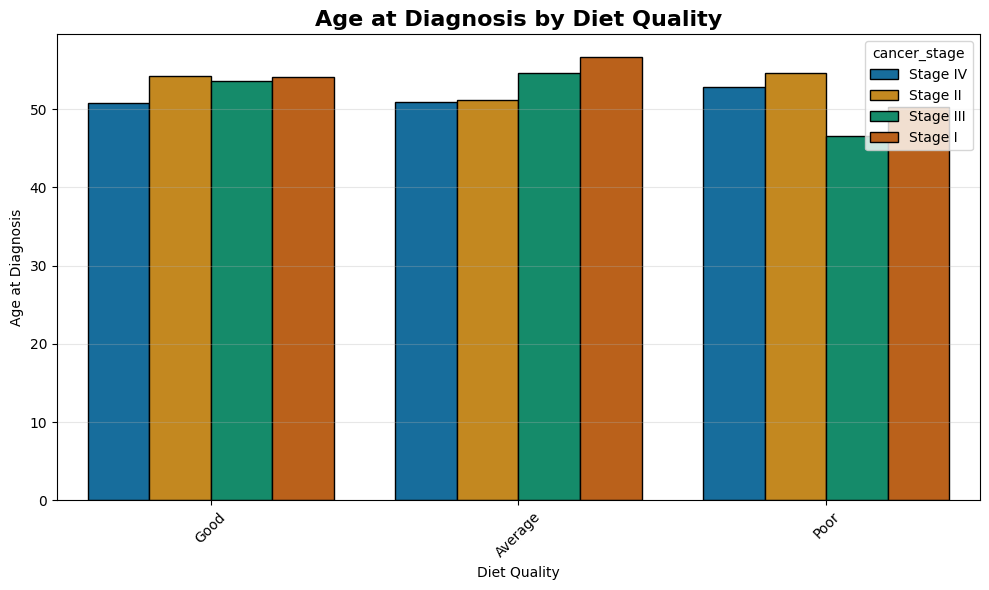


Findings: Eventhough patiets follow a good diet, results shows patients are still prone to cancer risk


In [40]:
try:
  # Risk to cancer based on Diet Quality
  print("Q5.a. Cancer Diagnosed age based on Patients Diet Quality")
  plt.figure(figsize=(10, 6))
  sns.barplot(data=df_clean, x='diet_quality', y='age_at_diagnosis', hue='cancer_stage', edgecolor="black",errorbar=None,palette="colorblind")
  plt.title("Age at Diagnosis by Diet Quality", fontsize=16, fontweight="bold")
  plt.xlabel("Diet Quality")
  plt.ylabel("Age at Diagnosis")
  plt.xticks(rotation=45)
  plt.grid(axis='y', alpha=0.3)
  plt.tight_layout()
  plt.show()

  print("\nFindings: Eventhough patiets follow a good diet, results shows patients are still prone to cancer risk")


except Exception as e:
  print(e)



Q5.b. How many people are in each cancer type?


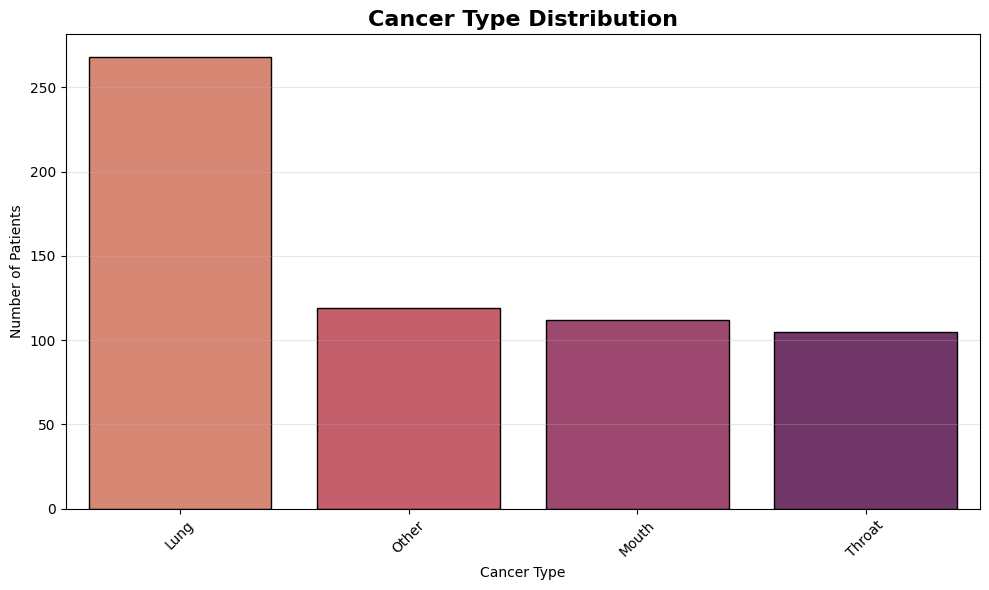


Findings: Majority of the patients are affected by Lung Cancer type


In [41]:
try:
  print("Q5.b. How many people are in each cancer type?")

  counts_df = (df_clean[["cancer_type"]].value_counts().reset_index(name="count"))
  plt.figure(figsize=(10,6))
  sns.barplot(data=counts_df,x="cancer_type",y="count",hue="cancer_type",palette="flare", edgecolor="black")
  plt.title("Cancer Type Distribution", fontsize=16, fontweight="bold")
  plt.xlabel("Cancer Type")
  plt.ylabel("Number of Patients")
  plt.xticks(rotation=45)
  plt.grid(axis='y', alpha=0.3)
  plt.tight_layout(),
  plt.show()

  print("\nFindings: Majority of the patients are affected by Lung Cancer type")
except Exception as e:
  print(e)

Q6. How does survival years differ from cancer treatment?


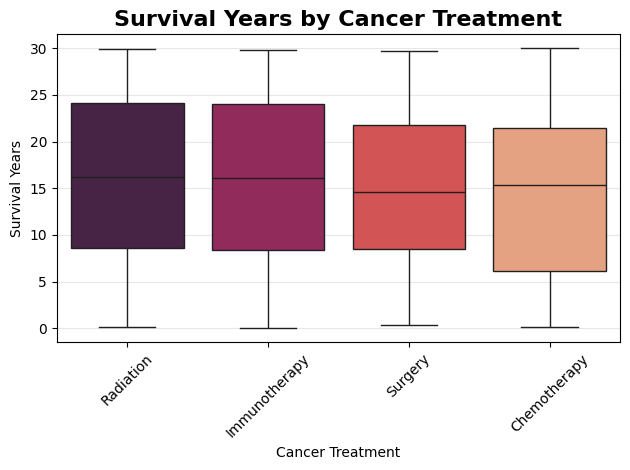


Findings: 'Radiation' and 'Immunotherapy' patients show higher survival years, while Surgery and Chemotherapy show lower survival durations.


In [42]:
try:
  # Survival years by Cancer treatment:
  print("Q6. How does survival years differ from cancer treatment?")
  sns.boxplot(data=df_clean, x='treatment_type', y='survival_years', hue='treatment_type', palette='rocket', legend=False)
  plt.title("Survival Years by Cancer Treatment", fontsize=16, fontweight="bold")
  plt.xlabel("Cancer Treatment")
  plt.ylabel("Survival Years")
  plt.xticks(rotation=45)
  plt.grid(axis='y', alpha=0.3),
  plt.tight_layout(),
  plt.show()

  print("\nFindings: 'Radiation' and 'Immunotherapy' patients show higher survival years, while Surgery and Chemotherapy show lower survival durations.")

except Exception as e:
  print(e)

Q7. How many patients under each treatment type by cancer stage?


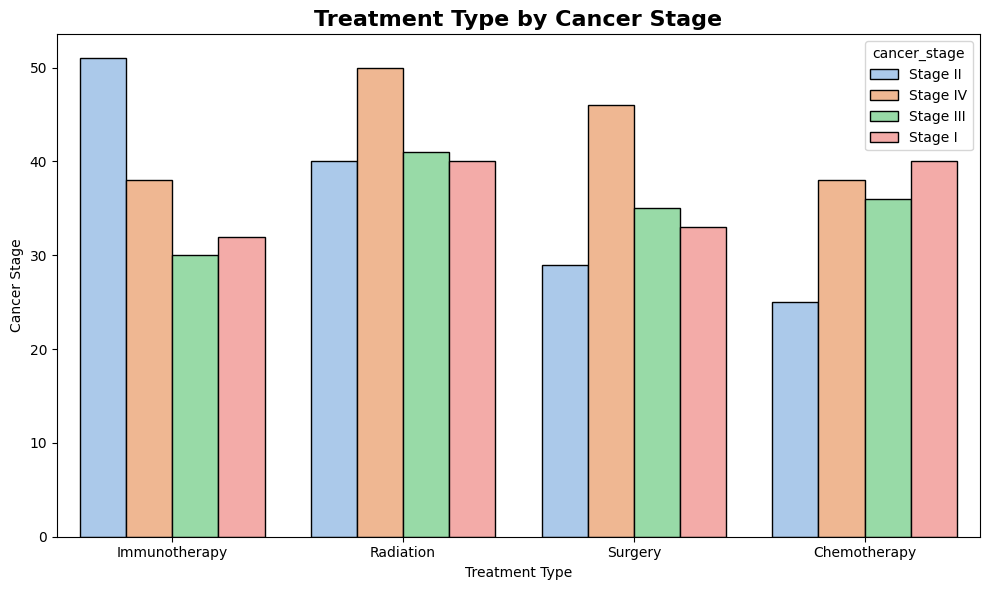


Findings: Chart shows 'Immunotherapy' treatment type has the highest patients for Stage I cancer, while 'Radiation and Surgery' treatment has Stage IV.


In [43]:
try:
  # How many patients under each treatment type by cancer stage
  print("Q7. How many patients under each treatment type by cancer stage?")

  counts_df = (df_clean[[ "treatment_type","cancer_stage"]].value_counts().reset_index(name="count"))
  plt.figure(figsize=(10,6))
  sns.barplot(data=counts_df, x="treatment_type", y="count", hue="cancer_stage", palette="pastel", edgecolor="black")
  plt.title("Treatment Type by Cancer Stage", fontsize=16, fontweight="bold")
  plt.xlabel("Treatment Type")
  plt.ylabel("Cancer Stage")
  plt.tight_layout()
  plt.show()

  print("\nFindings: Chart shows 'Immunotherapy' treatment type has the highest patients for Stage I cancer, while 'Radiation and Surgery' treatment has Stage IV.")

except Exception as e:
  print(e)


Q8. Is there a relationship between BMI, age, and survival status?


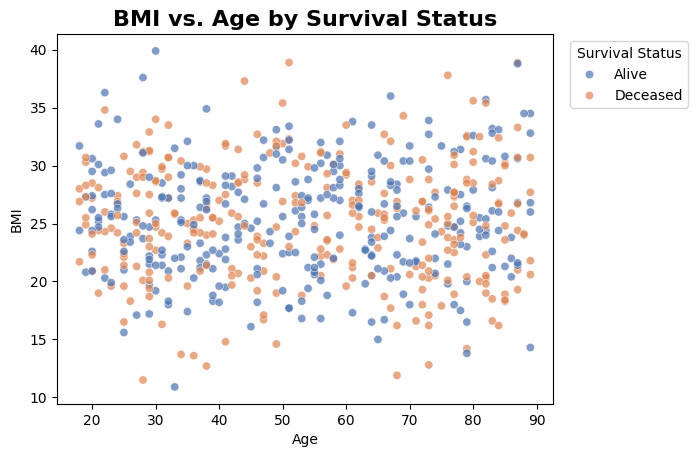


FIndings: No clear relationship between BMI and age, but survival status varies slightly across BMI levels


In [44]:
try:
  # BMI vs. Age by survival status
  print("Q8. Is there a relationship between BMI, age, and survival status?")

  sns.scatterplot(data = df_clean, x = 'age', y = 'bmi', hue='survival_status', palette="deep", alpha=0.7)
  plt.title("BMI vs. Age by Survival Status", fontsize=16, fontweight="bold")
  plt.xlabel("Age")
  plt.ylabel("BMI")
  plt.legend(title="Survival Status", bbox_to_anchor=(1.02, 1), loc="upper left")
  plt.show()

  print("\nFIndings: No clear relationship between BMI and age, but survival status varies slightly across BMI levels")

except Exception as e:
  print(e)

# End of Analysis